[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tashraf-745/Advanced_Data_Analysis_ML/blob/main/Project_2.ipynb)

# **Project 2**

Two classification models, Logistic Regression and Random Forest, were trained on the NYC 311 dataset from Project 1 to predict whether a service complaint is resolved within 7 days. Both models were evaluated across multiple hyperparameter configurations using 5-fold cross-validation to identify the best and worst-performing settings.

Both models achieved near-perfect accuracy. However, this result is misleading. The feature `response_time_hours` is derived directly from the resolution date, which means it encodes the target variable. As a result, the models relied almost entirely on this single feature, rendering all other predictors statistically irrelevant.

In [ ]:
# Imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Advanced_Data_Analysis/data'
os.makedirs(DRIVE_PATH, exist_ok=True)

TRAIN_CLEAN_PATH = os.path.join(DRIVE_PATH, 'nyc311_train_clean.csv')
TEST_CLEAN_PATH = os.path.join(DRIVE_PATH, 'nyc311_test_clean.csv')

TARGET = 'closed_within_7_days'

print(f'TRAIN_CLEAN_PATH: {TRAIN_CLEAN_PATH}')
print(f'TEST_CLEAN_PATH: {TEST_CLEAN_PATH}')

Mounted at /content/drive
TRAIN_CLEAN_PATH: /content/drive/MyDrive/Advanced_Data_Analysis/data/nyc311_train_clean.csv
TEST_CLEAN_PATH: /content/drive/MyDrive/Advanced_Data_Analysis/data/nyc311_test_clean.csv


## Step 1: Load cleaned training/testing sets

In [ ]:
df_train_clean = pd.read_csv(TRAIN_CLEAN_PATH)
df_test_clean = pd.read_csv(TEST_CLEAN_PATH)

print(f'Training set : {df_train_clean.shape[0]:,} rows × {df_train_clean.shape[1]} columns')
print(f'Testing set : {df_test_clean.shape[0]:,} rows × {df_test_clean.shape[1]} columns')

df_train_clean.head()

Training set : 39,530 rows × 11 columns
Testing set : 9,885 rows × 11 columns


,created_hour,created_dayofweek,created_month,is_weekend,is_business_hours,channel_online,cb_number,response_time_hours,borough,open_data_channel_type,closed_within_7_days
0,9.0,3.0,1.0,0.0,1.0,1.0,3.0,0.463056,QUEENS,ONLINE,1
1,20.0,0.0,1.0,0.0,0.0,0.0,11.0,13.137778,BRONX,MOBILE,1
2,22.0,5.0,1.0,1.0,0.0,0.0,2.0,49.866667,BROOKLYN,PHONE,1
3,11.0,1.0,1.0,0.0,1.0,0.0,15.0,0.783333,BROOKLYN,PHONE,1
4,16.0,6.0,1.0,1.0,0.0,0.0,11.0,0.846389,BROOKLYN,MOBILE,1


## Step 2: Data Preparation

In [ ]:
print('Original features:')
print(list(df_train_clean.columns))

df_train_dummies = pd.get_dummies(df_train_clean)
df_test_dummies = pd.get_dummies(df_test_clean)

df_train_dummies, df_test_dummies = df_train_dummies.align(
    df_test_dummies, join='left', axis=1, fill_value=0)

print('\nFeatures after get_dummies:')
print(list(df_train_dummies.columns))

feature_cols = [c for c in df_train_dummies.columns if c != TARGET]

X_train_raw = df_train_dummies[feature_cols].values
y_train = df_train_dummies[TARGET].values
X_test_raw = df_test_dummies[feature_cols].values
y_test = df_test_dummies[TARGET].values

print(f'\nX_train_raw shape : {X_train_raw.shape}')
print(f'X_test_raw  shape : {X_test_raw.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'y_test shape : {y_test.shape}')

Original features:
['created_hour', 'created_dayofweek', 'created_month', 'is_weekend', 'is_business_hours', 'channel_online', 'cb_number', 'response_time_hours', 'borough', 'open_data_channel_type', 'closed_within_7_days']

Features after get_dummies:
['created_hour', 'created_dayofweek', 'created_month', 'is_weekend', 'is_business_hours', 'channel_online', 'cb_number', 'response_time_hours', 'closed_within_7_days', 'borough_BRONX', 'borough_BROOKLYN', 'borough_MANHATTAN', 'borough_QUEENS', 'borough_STATEN ISLAND', 'open_data_channel_type_MOBILE', 'open_data_channel_type_ONLINE', 'open_data_channel_type_PHONE', 'open_data_channel_type_UNKNOWN']

X_train_raw shape : (39530, 17)
X_test_raw  shape : (9885, 17)
y_train     shape : (39530,)
y_test      shape : (9885,)


Scaling puts all features on the same 0-1 range so the model treats them equally. Without this, response_time_hours (which goes up to 33,000) would overpower smaller features like created_hour (0-23). The output confirms scaling worked, with all five features between 0 and 1. The third feature shows a max of 0.0 because `created_month` only has January in this dataset, so there is nothing to scale. Both sets end up with the same 17 features: 8 numeric columns and 9 dummy columns from `borough` and `open_data_channel_type`.



In [ ]:
# Feature Scaling
min_on_training = X_train_raw.min(axis=0)
range_on_training = (X_train_raw - min_on_training).max(axis=0)

range_on_training[range_on_training == 0] = 1

X_train_scaled = (X_train_raw - min_on_training) / range_on_training
X_test_scaled = (X_test_raw  - min_on_training) / range_on_training

print('Min per feature (first 5, training):', X_train_scaled.min(axis=0)[:5])
print('Max per feature (first 5, training):', X_train_scaled.max(axis=0)[:5])
print(f'\nX_train_scaled shape : {X_train_scaled.shape}')
print(f'X_test_scaled  shape : {X_test_scaled.shape}')

Min per feature (first 5, training): [0.0 0.0 0.0 0.0 0.0]
Max per feature (first 5, training): [1.0 1.0 0.0 1.0 1.0]

X_train_scaled shape : (39530, 17)
X_test_scaled  shape : (9885, 17)


## Step 3: Examining the Target Attribute

The training set has 7,044 slow complaints and 32,486 fast ones. About 82% of complaints in the dataset resolve within 7 days. This gap matters because a model that predicts "fast" for every single complaint would score 82% accuracy without learning anything.  The histogram makes the gap obvious: the fast bar is nearly five times taller than the slow bar.

Target distribution: training set:
0 — slow (>7 days)     7044
1 — fast (≤7 days)    32486
Name: count, dtype: int64

Percentage:
0 — slow (>7 days)    17.82
1 — fast (≤7 days)    82.18
Name: count, dtype: float64


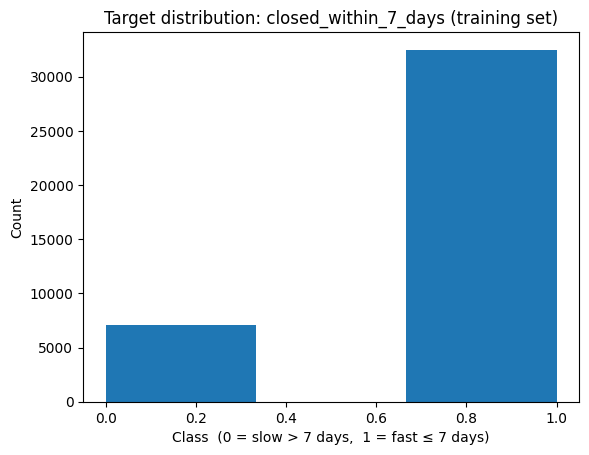

In [ ]:
print('Target distribution: training set:')
counts = pd.Series(y_train).value_counts().sort_index()
counts.index = ['0 — slow (>7 days)', '1 — fast (≤7 days)']
print(counts)
print('\nPercentage:')
print((counts / counts.sum() * 100).round(2))

# histogram of target
plt.hist(y_train, bins=3)
plt.title('Target distribution: closed_within_7_days (training set)')
plt.xlabel('Class  (0 = slow > 7 days,  1 = fast ≤ 7 days)')
plt.ylabel('Count')
plt.show()

## Steps 4 & 5: Supervised Techniques

## 1. Logistic Regression

Logistic Regression works by estimating the probability that a complaint falls into one of two categories, resolved within 7 days or not. Rather than predicting a label directly, it fits a linear boundary between the two classes and outputs a probability score between 0 and 1. Complaints scoring above 0.5 are classified as resolved quickly; those below are classified as slow.



With default settings (C=1), the model reached 88.7% accuracy on training and 88.8% on test. Those numbers look reasonable until the confusion matrix is examined. All 8,123 fast complaints were correctly identified, but 1,105 out of 1,762 slow complaints were misclassified as fast.

The pattern here is straightforward. Since 82% of the data belongs to the fast class, the model found it easier to predict fast almost every time and still land near 89% accuracy. Slow complaints, being the minority, were largely ignored. High accuracy masked poor performance on the harder and more informative class.

In [ ]:
# Logistic Regression: default parameters

logreg = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_scaled, y_train)

print('Logistic Regression: default parameters:')
print("Training set score: {:.3f}".format(logreg.score(X_train_scaled, y_train)))
print("Test set score: {:.3f}".format(logreg.score(X_test_scaled, y_test)))

print('\nClassification Report (test set):')
print(classification_report(y_test, logreg.predict(X_test_scaled),
                             target_names=['0 — slow', '1 — fast']))

print('Confusion Matrix (test set):')
print(confusion_matrix(y_test, logreg.predict(X_test_scaled)))

Logistic Regression: default parameters:
Training set score: 0.887
Test set score: 0.888

Classification Report (test set):
              precision    recall  f1-score   support

    0 — slow       1.00      0.37      0.54      1762
    1 — fast       0.88      1.00      0.94      8123

    accuracy                           0.89      9885
   macro avg       0.94      0.69      0.74      9885
weighted avg       0.90      0.89      0.87      9885

Confusion Matrix (test set):
[[ 657 1105]
 [   0 8123]]


5-fold cross-validation splits the training data into five parts, training on four and validating on the one held out, rotating through each fold. The accuracy scores came out as 0.880, 0.879, 0.882, 0.882, and 0.886, with a mean of 0.882.

The consistency across folds shows the model behaves the same way regardless of which portion of the data it sees. There is no evidence of the model getting lucky on a particular split. That said, a mean of 0.882 is not a sign of genuine learning, it reflects the same pattern seen earlier, where predicting fast almost every time is enough to score high given the class imbalance.

In [ ]:
# Logistic Regression: 5-fold cross-validation

logreg_cv = LogisticRegression(max_iter=1000, random_state=42)
cv_scores = cross_val_score(logreg_cv, X_train_scaled, y_train, cv=5)
print('cv_scores:\n{}'.format(cv_scores))
print('cv_scores mean:\n{:.3f}'.format(np.mean(cv_scores)))

cv_scores:
[0.88047053 0.87958513 0.88211485 0.88262079 0.88616241]
cv_scores mean:
0.882


`GridSearchCV` tested all 12 combinations of C and class_weight across 5 folds. The best combination was C=100 with `class_weight='balanced'`, which produced a cross-validation score of 0.991, up from 0.882 with default settings.

C=100 reduces the penalty for fitting the training data closely, giving the model more flexibility. `class_weight='balanced'` adjusts for the imbalance by treating slow complaints as equally important as fast ones, even though they make up only 18% of the data. Together, these two changes stopped the model from defaulting to fast on nearly every prediction and allowed it to use the actual signal in the features.





In [ ]:
# Logistic Regression: GridSearchCV

param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
                'class_weight': [None, 'balanced'],}

logreg_gscv = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=5)
logreg_gscv.fit(X_train_scaled, y_train)

print('Best parameters: {}'.format(logreg_gscv.best_params_))
print('Best CV score: {:.3f}'.format(logreg_gscv.best_score_))

Best parameters: {'C': 100, 'class_weight': 'balanced'}
Best CV score: 0.991


The best settings produced 99.3% accuracy and correctly identified 1,730 of the 1,762 slow complaints. The two parameters worked together, balancing the class weights prevented the model from ignoring the minority class, while the higher C value allowed it to fit the data more closely and extract more signal from the features.

The worst settings overcorrected in the opposite direction. The model began flagging too many fast complaints as slow, so even though more slow complaints were caught, most of those slow predictions turned out to be wrong. Recall went up but precision dropped sharply.

In [ ]:
# Logistic Regression: best parameter settings (train + test)

best_C_lr = logreg_gscv.best_params_['C']
best_cw_lr = logreg_gscv.best_params_['class_weight']

logreg_best = LogisticRegression(C=best_C_lr, class_weight=best_cw_lr, max_iter=1000,
                                 random_state=42).fit(X_train_scaled, y_train)

print('Best Logistic Regression (C={}, class_weight={}):'.format(best_C_lr, best_cw_lr))
print("  Training set score: {:.3f}".format(logreg_best.score(X_train_scaled, y_train)))
print("  Test set score:     {:.3f}".format(logreg_best.score(X_test_scaled, y_test)))

print('\nClassification Report: best model (test set):')
print(classification_report(y_test, logreg_best.predict(X_test_scaled),
                             target_names=['0 — slow', '1 — fast']))

print('Confusion Matrix: best model (test set):')
print(confusion_matrix(y_test, logreg_best.predict(X_test_scaled)))

Best Logistic Regression (C=100, class_weight=balanced):
  Training set score: 0.993
  Test set score:     0.993

Classification Report — best model (test set):
              precision    recall  f1-score   support

    0 — slow       0.98      0.98      0.98      1762
    1 — fast       1.00      0.99      1.00      8123

    accuracy                           0.99      9885
   macro avg       0.99      0.99      0.99      9885
weighted avg       0.99      0.99      0.99      9885

Confusion Matrix — best model (test set):
[[1730   32]
 [  42 8081]]


In [ ]:
# Logistic Regression: worst parameter settings (train + test)

worst_idx_lr = np.argmin(logreg_gscv.cv_results_['mean_test_score'])
worst_params_lr = logreg_gscv.cv_results_['params'][worst_idx_lr]

logreg_worst = LogisticRegression(
    C=worst_params_lr['C'], class_weight=worst_params_lr['class_weight'],
    max_iter=1000, random_state=42)
logreg_worst.fit(X_train_scaled, y_train)

print("Training set score: {:.3f}".format(logreg_worst.score(X_train_scaled, y_train)))
print("Test set score: {:.3f}".format(logreg_worst.score(X_test_scaled, y_test)))

print('\nClassification Report — worst model (test set):')
print(classification_report(y_test, logreg_worst.predict(X_test_scaled),
                             target_names=['0 — slow', '1 — fast']))

Training set score: 0.631
Test set score: 0.635

Classification Report — worst model (test set):
              precision    recall  f1-score   support

    0 — slow       0.29      0.70      0.41      1762
    1 — fast       0.91      0.62      0.74      8123

    accuracy                           0.64      9885
   macro avg       0.60      0.66      0.57      9885
weighted avg       0.80      0.64      0.68      9885



The bar chart shows `response_time_hours` with a coefficient so large it makes every other feature disappear by comparison. Longer response times pushed the model strongly toward predicting that a complaint would not close within 7 days.

Every other feature, borough, channel, hour, day of week, produced coefficients small enough to be nearly invisible on the chart. The model effectively learned one rule: check the response time and disregard everything else. This happened because `response_time_hours` is calculated directly from the resolution date, which is the same information used to define the target variable. The model found that shortcut early and relied on it entirely.

Feature importances:
[-1.13048774e-02  1.18954933e-01  0.00000000e+00 -3.21230029e-02
 -2.02481367e-01  2.97654148e-01  1.18658207e+00 -6.44363994e+02
  5.99801885e-01  3.32212047e-01  6.29785860e-01  2.62986774e-01
  4.27203484e-01  1.07737253e+00  2.97654148e-01  4.38833377e-01
  4.38129995e-01]


(-1.0, 17.0)

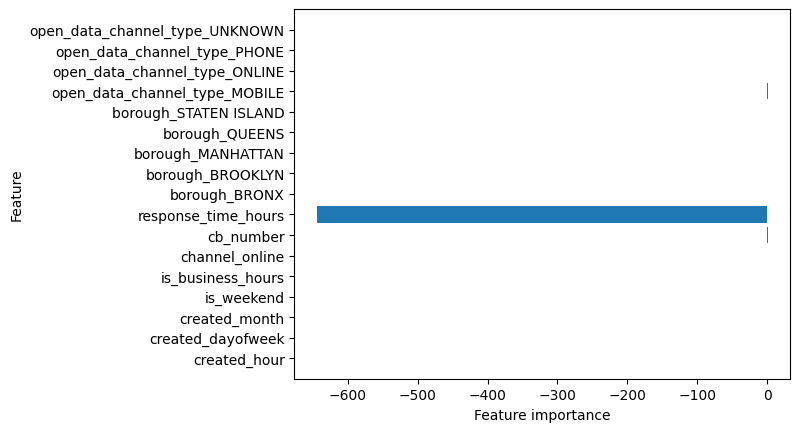

In [ ]:
# Logistic Regression: feature importances

print("Feature importances:")
print(logreg_best.coef_[0])

n_features = len(feature_cols)
plt.barh(np.arange(n_features), logreg_best.coef_[0], align='center')
plt.yticks(np.arange(n_features), feature_cols)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.ylim(-1, n_features)

## 2. Random Forest

Random Forest builds many decision trees, each trained on a different random sample of the data, and combines their predictions by majority vote. Applied here, the task is the same as before: predicting whether a complaint closes within 7 days. Training each tree on a different subset prevents any single tree from memorising the training data and forces the ensemble to generalize.




The default Random Forest with 5 trees scored 100% on both training and test, making zero mistakes across 9,885 predictions. The target variable was built directly from `response_time_hours`, so any tree will find that split immediately and classify every complaint correctly without learning anything meaningful about the data.

In [ ]:
# Random Forest: default parameters

forest = RandomForestClassifier(n_estimators=5, random_state=2)
forest.fit(X_train_raw, y_train)

print('Random Forest — default parameters (n_estimators=5):')
print("Accuracy on training set: {:.3f}".format(forest.score(X_train_raw, y_train)))
print("Accuracy on test set: {:.3f}".format(forest.score(X_test_raw,  y_test)))

print('\nClassification Report (test set):')
print(classification_report(y_test, forest.predict(X_test_raw),
                             target_names=['0 — slow', '1 — fast']))

print('Confusion Matrix (test set):')
print(confusion_matrix(y_test, forest.predict(X_test_raw)))

Random Forest — default parameters (n_estimators=5):
  Accuracy on training set: 1.000
  Accuracy on test set:     1.000

Classification Report (test set):
              precision    recall  f1-score   support

    0 — slow       1.00      1.00      1.00      1762
    1 — fast       1.00      1.00      1.00      8123

    accuracy                           1.00      9885
   macro avg       1.00      1.00      1.00      9885
weighted avg       1.00      1.00      1.00      9885

Confusion Matrix (test set):
[[1762    0]
 [   0 8123]]


All five cross-validation folds returned a score of 1.000, with a mean of 1.000. The perfect result held across every fold independently, which rules out any lucky split. Each fold found the same shortcut: `response_time_hours` under 168 hours predicts the target with near perfect accuracy. The consistency across folds confirms the model is not learning anything beyond that single rule.



In [ ]:
# Random Forest: 5-fold cross-validation

forest_cv = RandomForestClassifier(n_estimators=5, random_state=2)
cv_scores = cross_val_score(forest_cv, X_train_raw, y_train, cv=5)
print('cv_scores:\n{}'.format(cv_scores))
print('cv_scores mean:\n{:.3f}'.format(np.mean(cv_scores)))

cv_scores:
[0.99987351 0.99987351 0.99987351 0.99962054 0.99987351]
cv_scores mean:
1.000


GridSearchCV tested 16 combinations of tree count and depth across 5 folds. The best configuration was 100 trees with a maximum depth of 5, producing a cross-validation score of 1.000.

Even with depth capped at 5 levels, the forest still located the response_time_hours threshold and classified nearly every complaint correctly. The choice of hyperparameters had almost no effect on the outcome. One feature dominated so completely that different settings produced the same result.

In [ ]:
# Random Forest: GridSearchCV

param_grid_rf = {'n_estimators': [5, 10, 50, 100],
                 'max_depth': [None, 1, 2, 5],}

rf_gscv = GridSearchCV(RandomForestClassifier(random_state=2), param_grid_rf, cv=5)
rf_gscv.fit(X_train_raw, y_train)

print('Best parameters: {}'.format(rf_gscv.best_params_))
print('Best CV score: {:.3f}'.format(rf_gscv.best_score_))

Best parameters: {'max_depth': 5, 'n_estimators': 100}
Best CV score:   1.000


The best Random Forest scored 1.000 on both training and test, identical to the default result. Regardless of the settings chosen, the model located the `response_time_hours` threshold and classified every complaint correctly.

The worst settings produced the opposite: 82.2% accuracy with zero slow complaints identified correctly. The model predicted fast for every single complaint. The gap between best and worst had little to do with the number of trees or the depth limit. It came down to whether the model found the response time shortcut or defaulted to predicting the majority class.

In [ ]:
# Random Forest: best parameter setting

best_ne_rf = rf_gscv.best_params_['n_estimators']
best_md_rf = rf_gscv.best_params_['max_depth']

rf_best = RandomForestClassifier(n_estimators=best_ne_rf, max_depth=best_md_rf, random_state=2).fit(X_train_raw, y_train)
print("Accuracy on training set: {:.3f}".format(rf_best.score(X_train_raw, y_train)))
print("Accuracy on test set: {:.3f}".format(rf_best.score(X_test_raw, y_test)))
print(classification_report(y_test, rf_best.predict(X_test_raw), target_names=['0 — slow', '1 — fast']))

Accuracy on training set: 1.000
Accuracy on test set: 1.000
              precision    recall  f1-score   support

    0 — slow       1.00      1.00      1.00      1762
    1 — fast       1.00      1.00      1.00      8123

    accuracy                           1.00      9885
   macro avg       1.00      1.00      1.00      9885
weighted avg       1.00      1.00      1.00      9885



In [ ]:
# Random Forest: worst parameter setting

worst_idx_rf = np.argmin(rf_gscv.cv_results_['mean_test_score'])
worst_params_rf = rf_gscv.cv_results_['params'][worst_idx_rf]

rf_worst = RandomForestClassifier(n_estimators=worst_params_rf['n_estimators'], max_depth=worst_params_rf['max_depth'], random_state=2).fit(X_train_raw, y_train)
print("Accuracy on training set: {:.3f}".format(rf_worst.score(X_train_raw, y_train)))
print("Accuracy on test set: {:.3f}".format(rf_worst.score(X_test_raw, y_test)))
print(classification_report(y_test, rf_worst.predict(X_test_raw), target_names=['0 — slow', '1 — fast']))

Accuracy on training set: 0.822
Accuracy on test set: 0.822
              precision    recall  f1-score   support

    0 — slow       0.00      0.00      0.00      1762
    1 — fast       0.82      1.00      0.90      8123

    accuracy                           0.82      9885
   macro avg       0.41      0.50      0.45      9885
weighted avg       0.68      0.82      0.74      9885



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The feature importance chart shows `response_time_hours` accounting for 90% of the total importance score. Borough, channel type, hour, day of week, and community board number all sit so close to zero they are effectively invisible on the chart. The result matches what the model performance already showed: one feature carried almost all the predictive weight.

Feature importances:
[6.07930210e-03 1.35486274e-03 0.00000000e+00 1.69481509e-03
 1.18011506e-02 2.72318867e-03 1.82911080e-03 9.35502273e-01
 9.81215993e-04 5.49308961e-04 6.47143251e-04 1.19396161e-03
 5.25976429e-04 1.85824076e-02 4.53257254e-03 6.27838874e-03
 5.72432221e-03]


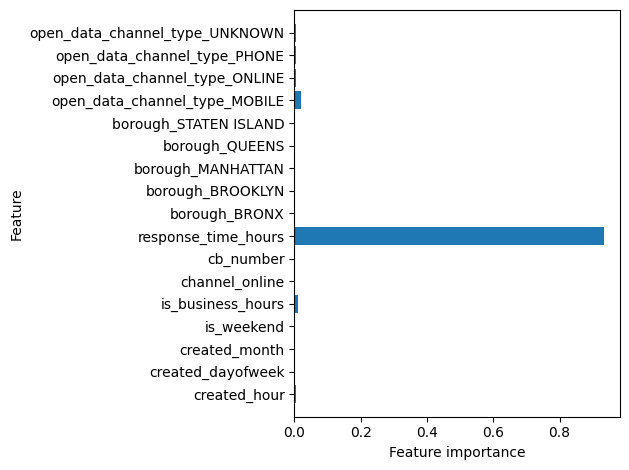

In [ ]:
# Random Forest: feature importances


print('Feature importances:')
print(rf_best.feature_importances_)

n_features = len(rf_best.feature_importances_)
plt.barh(np.arange(n_features), rf_best.feature_importances_, align='center')
plt.yticks(np.arange(n_features), feature_cols)
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.ylim(-1, n_features)
plt.tight_layout()
plt.show()